In [ ]:
!unzip cats_dogs_dataset.zip

Archive:  cats_dogs_dataset.zip
   creating: cats_dogs_dataset/
   creating: cats_dogs_dataset/test/
   creating: cats_dogs_dataset/test/cats/
   creating: cats_dogs_dataset/test/dogs/
   creating: cats_dogs_dataset/train/
   creating: cats_dogs_dataset/train/cats/
  inflating: cats_dogs_dataset/train/cats/809.jpg  
  inflating: cats_dogs_dataset/train/cats/81.jpg  
  inflating: cats_dogs_dataset/train/cats/810.jpg  
  inflating: cats_dogs_dataset/train/cats/811.jpg  
  inflating: cats_dogs_dataset/train/cats/812.jpg  
  inflating: cats_dogs_dataset/train/cats/813.jpg  
  inflating: cats_dogs_dataset/train/cats/814.jpg  
  inflating: cats_dogs_dataset/train/cats/815.jpg  
  inflating: cats_dogs_dataset/train/cats/82.jpg  
  inflating: cats_dogs_dataset/train/cats/83.jpg  
  inflating: cats_dogs_dataset/train/cats/8387.jpg  
  inflating: cats_dogs_dataset/train/cats/8388.jpg  
  inflating: cats_dogs_dataset/train/cats/8389.jpg  
  inflating: cats_dogs_dataset/train/cats/839.jpg  
  infl

Found 3598 images belonging to 2 classes.
Found 400 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
 58/100 ━━━━━━━━━━━━━━━━━━━━ 9s 230ms/step - acc: 0.5056 - loss: 0.7002

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 261ms/step - acc: 0.5144 - loss: 0.6954 - val_acc: 0.5000 - val_loss: 0.6915
Epoch 2/100
  1/100 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.4688 - loss: 0.6974

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - acc: 0.5352 - loss: 0.6912 - val_acc: 0.5900 - val_loss: 0.6868
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 239ms/step - acc: 0.5481 - loss: 0.6873 - val_acc: 0.6050 - val_loss: 0.6765
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - acc: 0.5769 - loss: 0.6812 - val_acc: 0.5750 - val_loss: 0.6756
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 240ms/step - acc: 0.5789 - loss: 0.6743 - val_acc: 0.5575 - val_loss: 0.6806
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - acc: 0.6058 - loss: 0.6604 - val_acc: 0.5025 - val_loss: 0.7364
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 236ms/step - acc: 0.5789 - loss: 0.6697 - val_acc: 0.5925 - val_loss: 0.6732
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - acc: 0.6562 - loss: 0.6436 - val_acc: 0.6075 - val_loss: 0.6681
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 234ms/step - acc: 0.5792 - loss: 0.6666 - val_acc: 0.5750 - val_loss: 0.6708
Epoch 10/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s

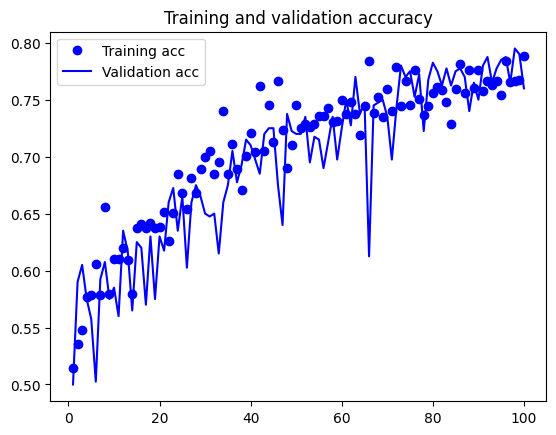

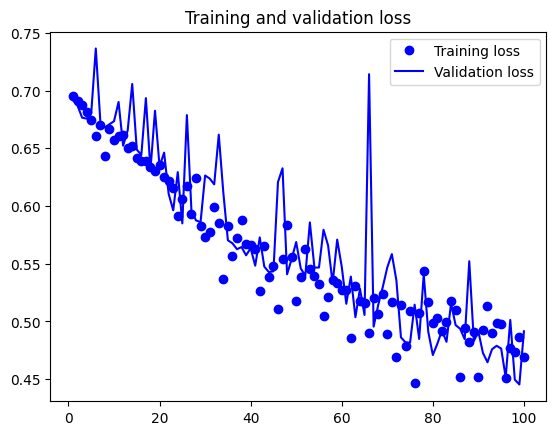

In [ ]:
#Keras Model with Image Augmentation and Dropout to reduce overfitting
from keras import layers
from keras import models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir="/content/cats_dogs_dataset/train/"
validation_dir="/content/cats_dogs_dataset/validation/"

train_datagen = ImageDataGenerator(
rescale=1./255,
rotation_range=40,
width_shift_range=0.2,
height_shift_range=0.2,
shear_range=0.2,
zoom_range=0.2,
horizontal_flip=True,)

#Validation Data Set should not be augmented
test_datagen = ImageDataGenerator(rescale=1./255)
#Resize all images to 150x150
train_generator = train_datagen.flow_from_directory(train_dir,target_size=(150, 150),batch_size=32,class_mode='binary')
validation_generator = test_datagen.flow_from_directory(
validation_dir,target_size=(150, 150),batch_size=32,class_mode='binary')




model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

from keras import optimizers
model.compile(loss='binary_crossentropy',optimizer=optimizers.RMSprop(learning_rate=1e-4),metrics=['acc'])

history = model.fit(
train_generator,
steps_per_epoch=100,
epochs=100,
validation_data=validation_generator,
validation_steps=50)

model.save('cats_and_dogs_small_2.h5')

import matplotlib.pyplot as plt
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()